In [ ]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import logging
logging.basicConfig(level=logging.INFO, 
                    format='%(filename)s:%(lineno)d - %(levelname)s - %(message)s')

import os
from aind_dynamic_foraging_population_analysis.model_comparison import (
    get_all_model_metrics,
    enrich_with_df_session,
    compare_models_across_curriculum,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
df_model_fitting = get_all_model_metrics(
    use_cache=True, cache_path=os.path.expanduser("~/capsule/results/df_model_fitting_all.pkl")
)
df_model_fitting = enrich_with_df_session(
    df_model_fitting,
    selected_fields=[
        "nwb_suffix",
        "curriculum_name",
        "curriculum_version",
        "curriculum_version_group",
        "current_stage_actual",
    ],
)

model_comparison.py:43 - INFO - Trying to load data from cache: /Users/han.hou/capsule/results/df_model_fitting_all.pkl...
model_comparison.py:45 - INFO - 200374 rows loaded from cache.
model_comparison.py:77 - INFO - Fetching session table...
han_pipeline.py:51 - INFO - Loading session table from s3://aind-behavior-data/foraging_nwb_bonsai_processed ...
han_pipeline.py:55 - INFO - Loading mouse PI mapping from s3://aind-behavior-data/foraging_nwb_bonsai_processed ...
han_pipeline.py:64 - INFO - Post-hoc processing...
han_pipeline.py:306 - INFO - Loaded curriculum data from Han's autotrain.
han_pipeline.py:315 - INFO - Loading curriculum data from docDB...
han_pipeline.py:368 - INFO - Loaded 9 curriculum data from docDB.
model_comparison.py:80 - INFO - Merging model fitting data with session data...


In [10]:
session_keys = ["subject_id", "session_date"]
required_aliases = {
    "QLearning_L1F0_epsi",
    "QLearning_L1F1_CK1_softmax",
    "QLearning_L2F1_softmax",
    "WSLS",
    "QLearning_L2F1_CKfull_softmax",
    "ForagingCompareThreshold",
}

grouped = df_model_fitting.groupby(session_keys)['agent_alias'].unique()
sessions_with_all_aliases = grouped[grouped.apply(lambda x: required_aliases.issubset(set(x)))].index.tolist()
sessions_with_all_aliases

# Only keep sessions that have all required aliases
df_filtered = df_model_fitting.set_index(session_keys).loc[sessions_with_all_aliases].reset_index()
df_filtered = df_filtered[df_filtered['agent_alias'].isin(required_aliases)]

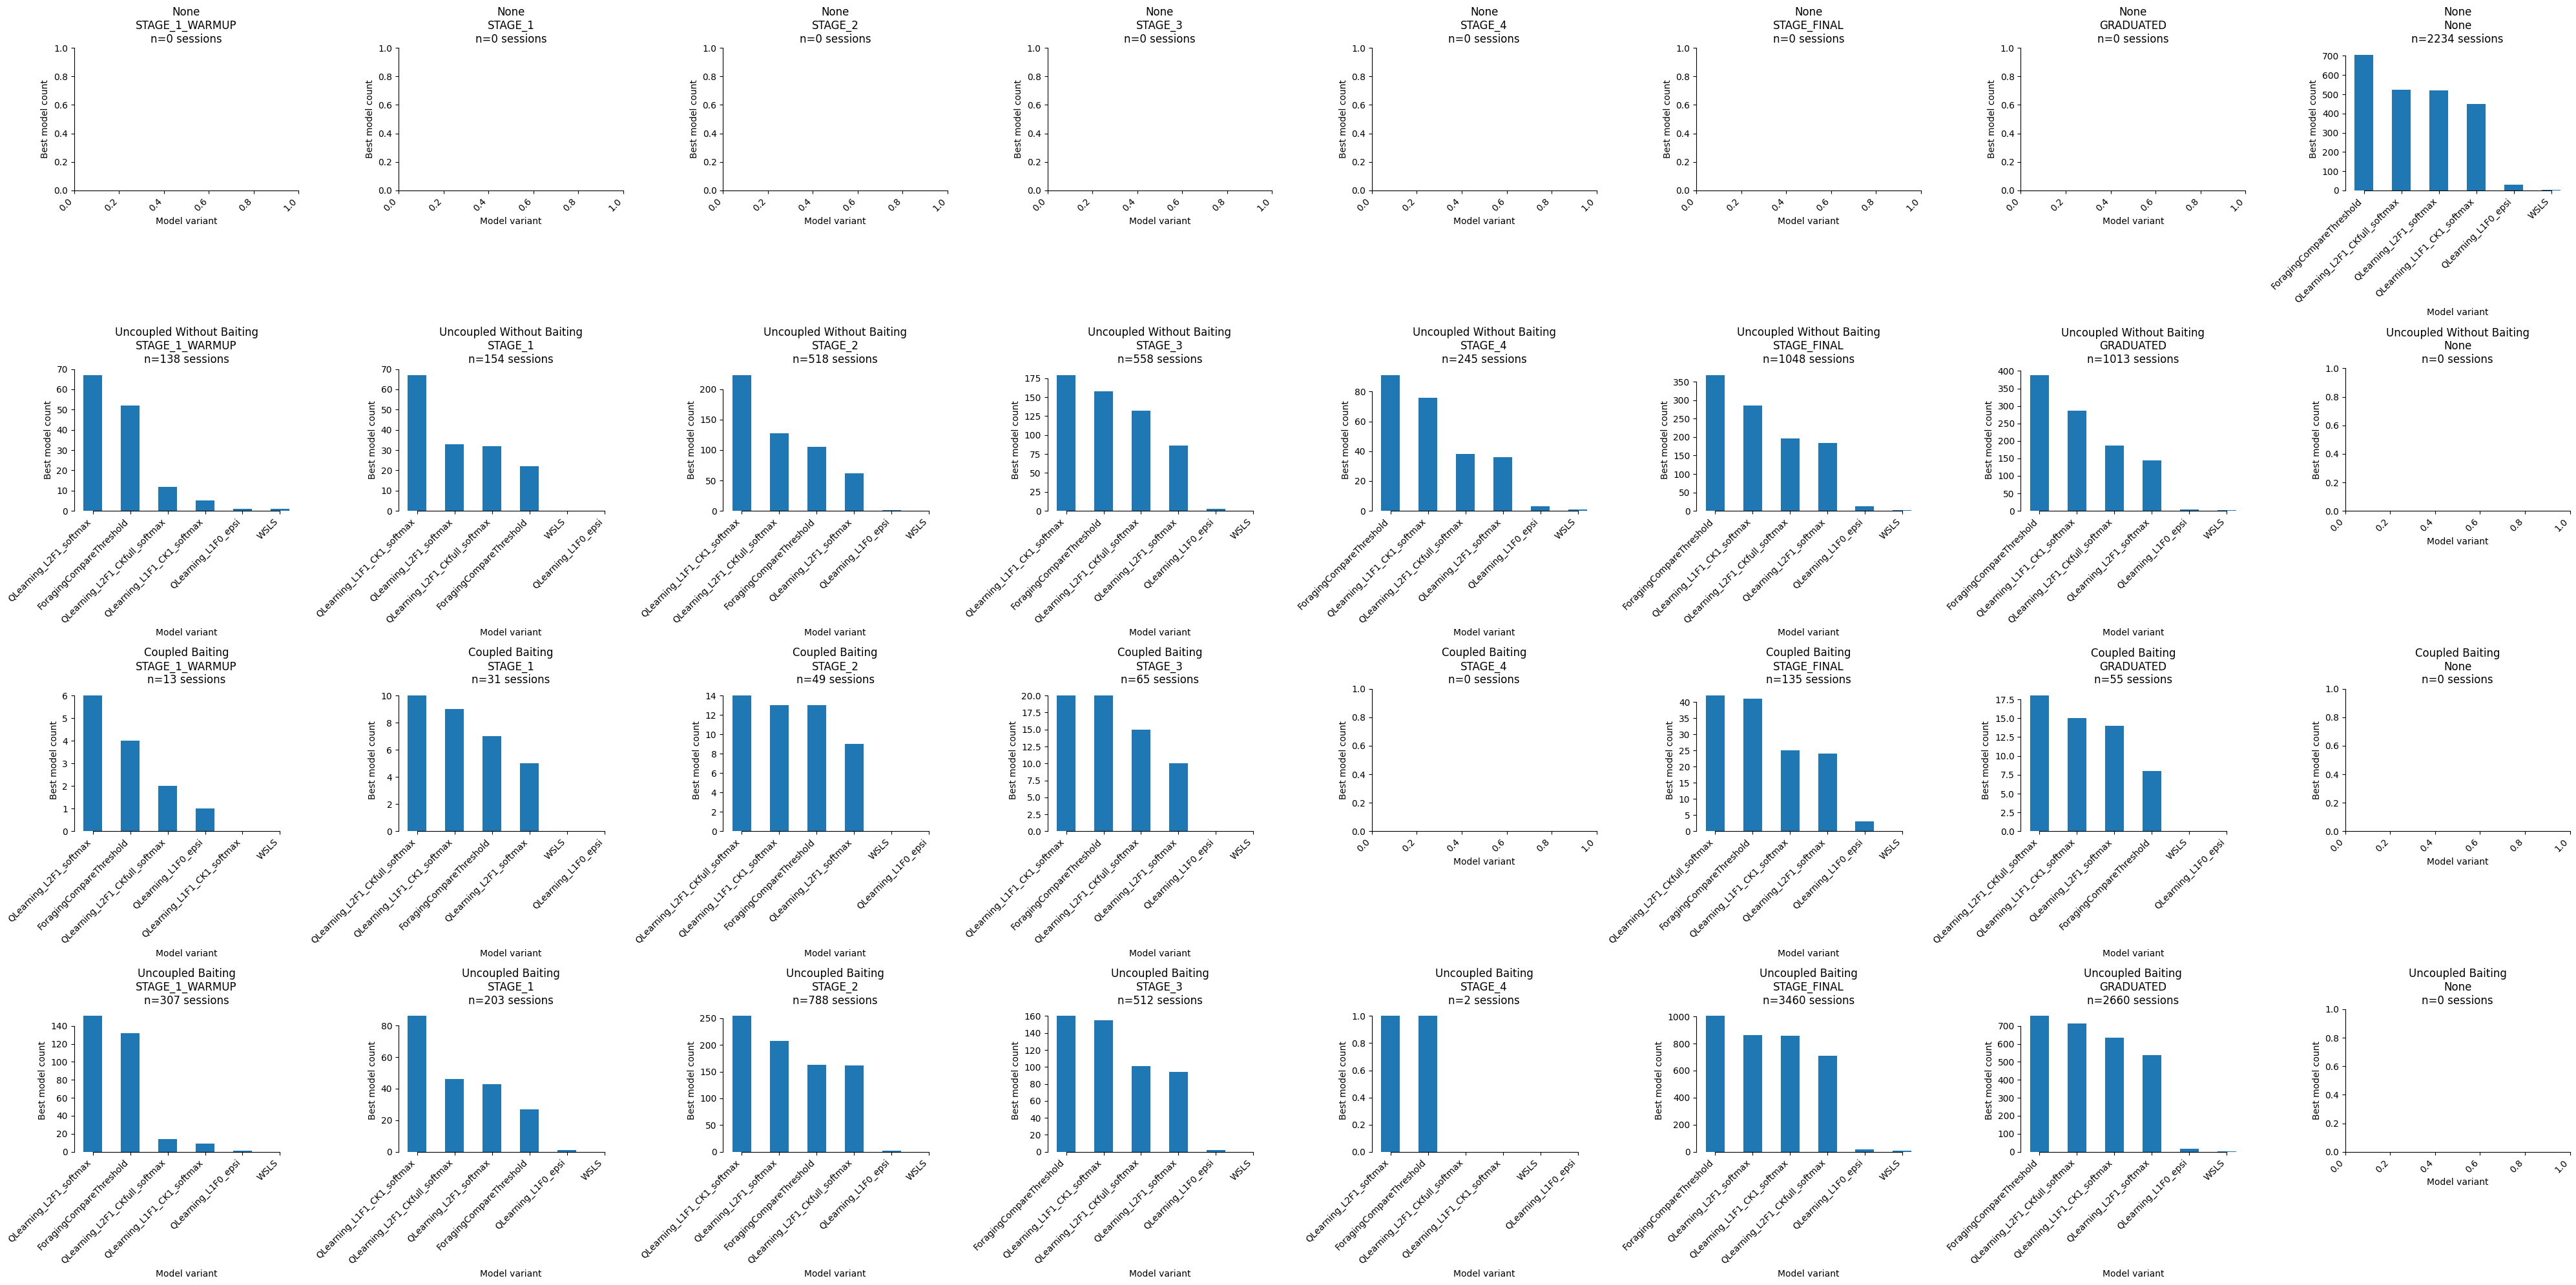

In [14]:
fig_AIC, _ = compare_models_across_curriculum(df_filtered, metrics="AIC")
fig_AIC.savefig("CTT_AIC.pdf", bbox_inches='tight')

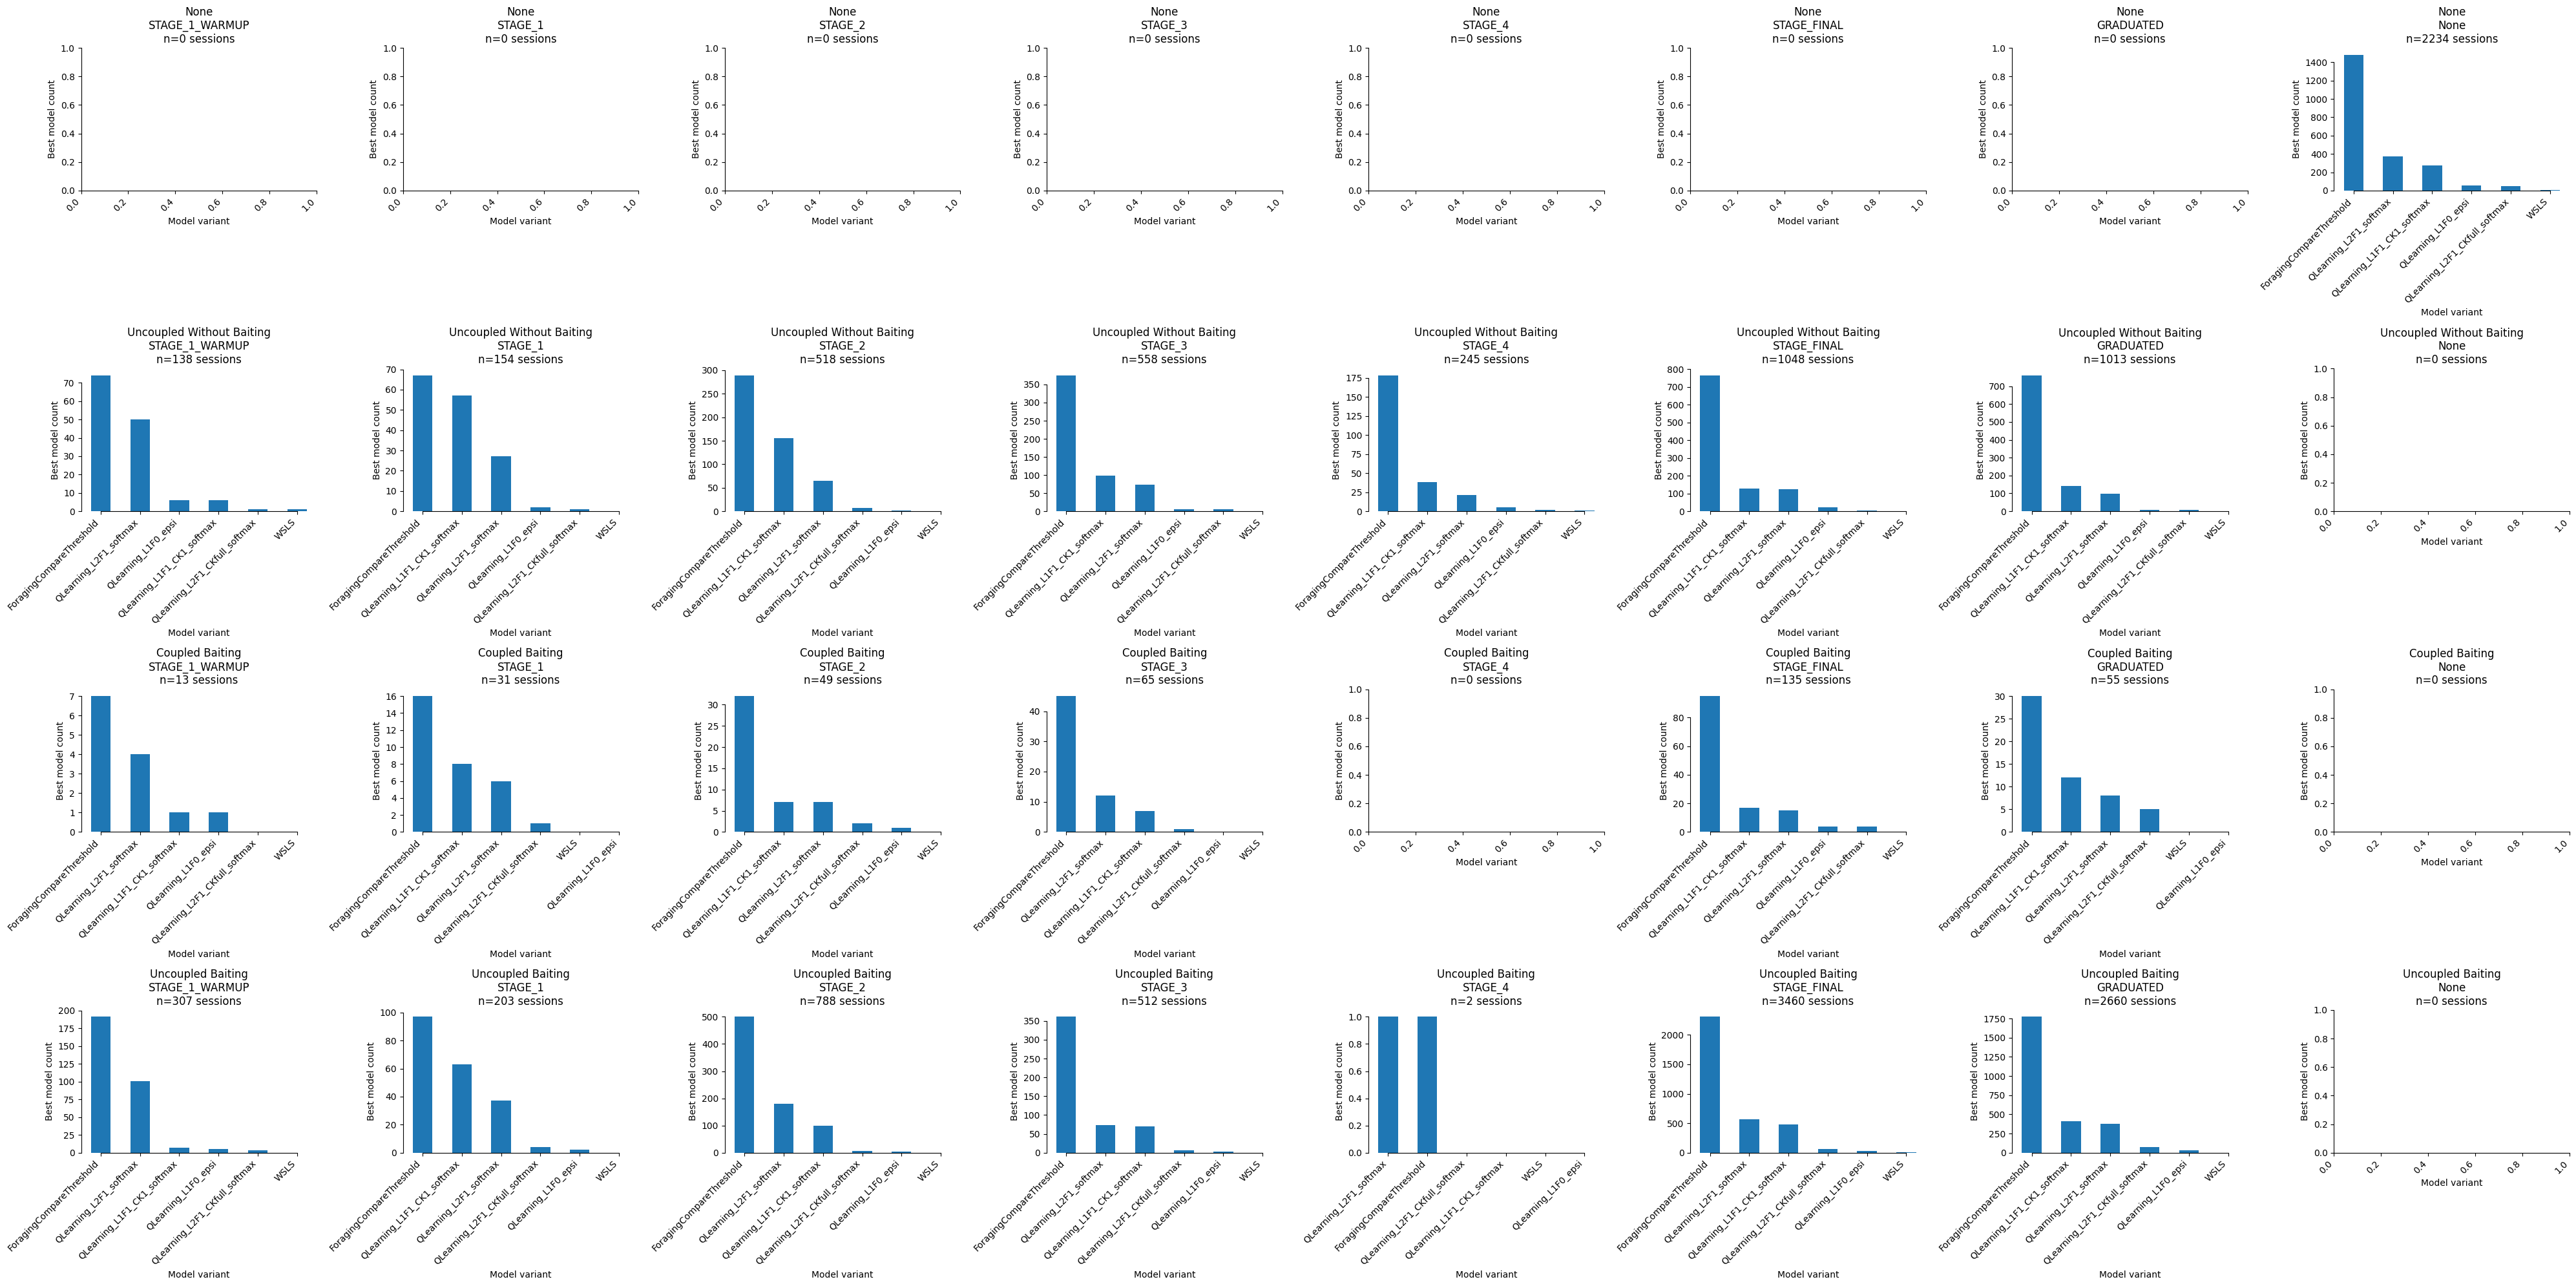

In [15]:
fig_BIC, _ = compare_models_across_curriculum(df_filtered, metrics="BIC")
fig_BIC.savefig("CTT_BIC.pdf", bbox_inches='tight')